02 · PEST setup - pilot points, time multipliers, observations, forecasts (3-layer GLM)



1. Imports

In [28]:
from pathlib import Path
import json, shutil, subprocess
import numpy as np, pandas as pd
import flopy, pyemu
import matplotlib.pyplot as plt
from helper_fb3_02_v1 import (property_table, time_mult_bounds, obs_order, read_history_csv,
                              temporal_cov, plot_pilot_points, plot_variogram, plot_cov)

2. Paths (reference for structure; CSV for observations; truth never read)

In [29]:
from paths import REFERENCE_TEMPLATE, HISTORY_OBS_CSV as HIST_CSV, PEST_TEMPLATE as TEMPLATE
MF6_EXE = r"c:\gwmodel\.venv\Scripts\mf6.exe"
MODEL_NAME = "frb3l_cal"
if TEMPLATE.exists(): shutil.rmtree(TEMPLATE)
TEMPLATE.mkdir(parents=True)
print("template:", TEMPLATE)

template: C:\workspace\gwmodeling\model_enhanced_fr\runs\pest_template


3. Settings (history/forecast timing match 01)

In [30]:
HISTORY_SP = list(range(2, 14))          # SP2-13
TAILWATER_FORECAST_SP, HEADWATER_FORECAST_SP, GW3_FORECAST_SP = 13, 22, 22
NPER = 25; N_TRANS = NPER - 1

PP_SPACE = 6                              # pilot-point spacing (reduced-parameter; tunable)
SPATIAL_RANGE_M = 1000.0                  # 4-cell exponential range (matches 01)
TEMPORAL_RANGE_MONTHS = 3.0

GW = {"gw_1": (2, 2, 9), "gw_2": (2, 33, 7), "gw_3": (0, 9, 1)}   # 0-based, from 01
print("history SP:", HISTORY_SP[0], "-", HISTORY_SP[-1], "| forecasts SP:", TAILWATER_FORECAST_SP, HEADWATER_FORECAST_SP, GW3_FORECAST_SP)

history SP: 2 - 13 | forecasts SP: 13 22 22


4. Load the reference model (structure only) and copy geometry 
: grid, top, botm, idomain, initial head, stress-period data, wells, recharge, GHB, SFR

In [31]:
# Load the reference MF6 simulation and gwf model
ref_sim = flopy.mf6.MFSimulation.load(sim_ws=str(REFERENCE_TEMPLATE), verbosity_level=0)
ref_gwf = ref_sim.get_model()

# Read model grid dimensions and cell sizes
nlay = ref_gwf.dis.nlay.array
nrow = ref_gwf.dis.nrow.array
ncol = ref_gwf.dis.ncol.array

delr = ref_gwf.dis.delr.array
delc = ref_gwf.dis.delc.array

# Read model geometry and initial conditions
top = ref_gwf.dis.top.array.copy()    # [m]
botm = ref_gwf.dis.botm.array.copy()  # [m[], shape: (nlay, nrow, ncol)
idomain = ref_gwf.dis.idomain.array.copy().astype(int) # 1= active / 0= inactive cell 
strt = ref_gwf.ic.strt.array.copy()   # starting head (initial head [m])

# Read stress-period timing information
tdis_pd = ref_sim.tdis.perioddata.get_data()

# Read well locations and pumping rates
ref_well_cells = [tuple(r["cellid"]) for r in ref_gwf.wel.stress_period_data.get_data()[0]]  #(layer, row, column)

# Pumping magnitudes for all wells and stress periods
ref_wel = np.array([[ -float(r["q"]) for r in ref_gwf.wel.stress_period_data.get_data()[t]]
                    for t in range(NPER)]).T        # (6, nper) row: well index; column: stress period; - -> pumping magnitude

# Read one recharge value for each stress period
ref_rch = np.array([float(np.unique(ref_gwf.rcha.recharge.get_data()[t])[0]) for t in range(NPER)])

# Read GHB data
ref_ghb = ref_gwf.ghb.stress_period_data.get_data(0) # GHB records of SP1; location of GHB cell, boundary head, conductance

# Read streamflow-routing data
sfr_pkg = ref_gwf.sfr.packagedata.get_data().copy()   # static properties for each reach (e.g., cell ID, length, elevation, width, k)
sfr_con = ref_gwf.sfr.connectiondata.get_data()       # reach connection topology
sfr_per = ref_gwf.sfr.perioddata.get_data()           # time-dependent boundary conditions (e.g., inflow, runoff, diversion)
nreaches = sfr_pkg.shape[0]                           # Total number of stream reaches
print("active per layer:", [int((idomain[k] > 0).sum()) for k in range(nlay)], "| nreaches:", nreaches)

active per layer: [706, 706, 706] | nreaches: 40


5. Prior-mean base property fields (homogeneous geomean of Table 1 bounds)

In [32]:
# Load the table of prior property bounds and base values
pt = property_table()

# Create a uniform 2D field using the base value for one property
def base_field(name):
    return np.full(
        (nrow, ncol),
        float(pt.loc[pt.name == name, "base"].iloc[0]),
    )

# Create homogeneous base K fields for L1–3
HK_BASE = np.stack([base_field(f"hk_l{k+1}") for k in range(3)])

# Create homogeneous base K33 fields for L1–3
VK_BASE = np.stack([base_field(f"vk_l{k+1}") for k in range(3)])

# Create homogeneous base Ss fields for L1–3
SS_BASE = np.stack([base_field(f"ss_l{k+1}") for k in range(3)])

# Create a homogeneous base Sy field for L1
SY_BASE = base_field("sy_l1")

# Save the base fields as text files for the next FW model
for k in range(3):
    np.savetxt(TEMPLATE / f"hk_base_l{k+1}.dat", HK_BASE[k])
    np.savetxt(TEMPLATE / f"vk_base_l{k+1}.dat", VK_BASE[k])
    np.savetxt(TEMPLATE / f"ss_base_l{k+1}.dat", SS_BASE[k])

# Save the L1 specific-yield base field
np.savetxt(TEMPLATE / "sy_base_l1.dat", SY_BASE)


In [33]:
# from matplotlib.colors import LogNorm

# # Print the base K value used for each layer
# print(
#     "HK base per layer:",
#     [float(HK_BASE[k, 0, 0]) for k in range(3)],
#     "(geomean of bounds)",
# )

# # Choose one base parameter to inspect
# arr = HK_BASE
# name = "Horizontal hydraulic conductivity, K"
# unit = "m/d"

# # Mask inactive cells
# plot_data = [
#     np.ma.masked_where(idomain[k] <= 0, arr[k])
#     for k in range(nlay)
# ]

# # Common logarithmic colour scale across Layers 1–3
# values = np.concatenate([x.compressed() for x in plot_data])
# norm = LogNorm(vmin=values.min(), vmax=values.max())

# fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

# for k, ax in enumerate(axes):
#     im = ax.imshow(
#         plot_data[k],
#         origin="upper",
#         cmap="cividis",
#         norm=norm,
#         interpolation="none",
#     )
#     ax.set_title(f"Layer {k + 1}")
#     ax.set_xlabel("Column")
#     ax.set_ylabel("Row")

# cbar = fig.colorbar(im, ax=axes, shrink=0.9)
# cbar.set_label(f"{name} ({unit})")

# fig.suptitle("Homogeneous prior-mean base field", fontsize=14)
# plt.show()

6. Build the calibration MF6 model (reference structure, prior-mean properties)

- Same packages/options as notebook 01 (NEWTON, 20/20 SFR split + obs, head obs, GHB, wells), but the
properties start at the homogeneous prior mean (previous cell); pilot-point multipliers (next cells) perturb them at
run time via forward_run.py.

In [34]:
# Create the calibration simulation in the PEST template workspace
sim = flopy.mf6.MFSimulation(sim_name=MODEL_NAME, version="mf6", exe_name=MF6_EXE, sim_ws=str(TEMPLATE))

# Copy stress-period timing from the reference model
flopy.mf6.ModflowTdis(sim, time_units="DAYS", nper=NPER, perioddata=tdis_pd)

# Set the iterative solver options
flopy.mf6.ModflowIms(
    sim,
    complexity="SIMPLE",
    outer_dvclose=0.01,           # Convergence criterion for outer iteration
    outer_maximum=100,            # Maximum number of outer iterations
    under_relaxation="DBD",       # Under-relaxation method (Damped-Benson-Day)
    under_relaxation_theta=0.85,  # Damping factor
    under_relaxation_kappa=1e-5,  # Kappa parameter
    under_relaxation_gamma=0.0,   # Gamma parameter
    under_relaxation_momentum=0.1,# Momentum parameter
    backtracking_number=50,       # Max number of backtracking steps
    backtracking_tolerance=1.1,   # Tolerance for backtracking
    backtracking_reduction_factor=0.7, # Factor to reduce step size
    backtracking_residual_limit=100.0, # Residual limit for backtracking
    inner_maximum=50,             # Maximum number of inner iterations
    inner_dvclose=1e-4,           # Convergence criterion for inner iteration
    rcloserecord=[0.1, "strict"], # Residual closure criteria
    linear_acceleration="BICGSTAB", # Linear acceleration method
    preconditioner_levels=1,      # Preconditioner fill level
    preconditioner_drop_tolerance=0.001, # Drop tolerance
    number_orthogonalizations=2,  # Number of orthogonalizations
    reordering_method="RCM",      # Matrix reordering method (Reverse Cuthill-McKee)
)

# Create the gwf model with Newton-Raphson formulation
gwf = flopy.mf6.ModflowGwf(sim, modelname=MODEL_NAME, save_flows=True, newtonoptions="NEWTON")

# Copy the reference grid and layer geometry
flopy.mf6.ModflowGwfdis(gwf, length_units="METERS", nlay=nlay, nrow=nrow, ncol=ncol,
                        delr=delr, delc=delc, top=top, botm=botm, idomain=idomain)

# Use the reference initial-head field
flopy.mf6.ModflowGwfic(gwf, strt=strt)

# Assign homogeneous prior-mean K and K33 fields
# L1 is convertible (unconfined); L2–3 are confined
flopy.mf6.ModflowGwfnpf(gwf, icelltype=[1,0,0], k=HK_BASE, k33=VK_BASE, save_flows=True)

# Assign homogeneous prior-mean storage fields
# Sy applies only to L1
flopy.mf6.ModflowGwfsto(gwf, iconvert=[1,0,0], ss=SS_BASE,
                        sy=np.stack([SY_BASE, np.zeros((nrow,ncol)), np.zeros((nrow,ncol))]),
                        steady_state={0: True}, transient={1: True}, save_flows=True)

# Copy GHB conditions from the reference model
flopy.mf6.ModflowGwfghb(gwf, stress_period_data={0: ref_ghb}, save_flows=True)

# Copy baseline pumping rates for all wells and stress periods
well_spd = {t: [[ref_well_cells[w], -ref_wel[w, t]] for w in range(len(ref_well_cells))] for t in range(NPER)}

flopy.mf6.ModflowGwfwel(gwf, stress_period_data=well_spd, save_flows=True)

# Copy baseline recharge values to active Layer 1 cells
flopy.mf6.ModflowGwfrcha(gwf, readasarrays=True,
                         recharge={t: np.where(idomain[0] > 0, ref_rch[t], 0.0) for t in range(NPER)},
                         save_flows=True)
print("base packages built")

base packages built


7. SFR + observations (identical to 01: 20/20 split, sw_1=INFLOW reach idx 39)

In [35]:
# Label SFR reaches by name for observation grouping
sfr_pkg["boundname"][:20] = "headwater_tm"
sfr_pkg["boundname"][20:] = "tailwater_tm"

# Define SFR observation points (exchange fluxes and inflow)
sfr_obs = {"cal_sfr_obs.csv": [("headwater_exchange", "SFR", "headwater_tm"),
                                ("tailwater_exchange", "SFR", "tailwater_tm"),
                                ("sw_1", "INFLOW", 39)]}

# Initialize and add SFR package to the gwf model
flopy.mf6.ModflowGwfsfr(gwf, nreaches=nreaches, packagedata=sfr_pkg, connectiondata=sfr_con,
                        perioddata=sfr_per, boundnames=True, unit_conversion=86400.0,
                        maximum_depth_change=1e-4, save_flows=True, observations=sfr_obs, pname="SFR")

# Set up gw head observations
flopy.mf6.ModflowUtlobs(gwf, print_input=False,
                        continuous={"cal_heads_obs.csv": [("gw_1","HEAD",GW["gw_1"]),
                                                          ("gw_2","HEAD",GW["gw_2"]),
                                                          ("gw_3","HEAD",GW["gw_3"])]})

# Configure Output Control (OC) to save heads and budget files
flopy.mf6.ModflowGwfoc(gwf, head_filerecord=f"{MODEL_NAME}.hds", budget_filerecord=f"{MODEL_NAME}.cbc",
                        saverecord=[("HEAD","ALL"),("BUDGET","ALL")])

sim.write_simulation()
print("calibration model written to", TEMPLATE)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model frb3l_cal...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package ghb_0...
INFORMATION: maxbound in ('', 'ghb', 'dimensions') changed to 30 based on size of stress_period_data
    writing package wel_0...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 6 based on size of stress_period_data
    writing package rcha_0...
    writing package sfr...
    writing package obs_0...
    writing package obs_1...
    writing package oc...
calibration model written to C:\workspace\gwmodeling\model_enhanced_fr\runs\pest_template


8. Pilot points (one location set, shared by all 10 property fields)

In [36]:
# Set up Spatial Reference for grid coordinates (either from namfile or custom origin)
sr = pyemu.helpers.SpatialReference.from_namfile(str(TEMPLATE / f"mfsim.nam"),
                                                delr=delr, delc=delc) if False else \
     pyemu.helpers.SpatialReference(delr=delr, delc=delc, xul=0.0, yul=nrow*float(delc[0]))

# Define the model parameters to be estimated via pilot points
PROPS = ["hk_l1","hk_l2","hk_l3","vk_l1","vk_l2","vk_l3","ss_l1","ss_l2","ss_l3","sy_l1"] #10 

# Generate pilot points on a grid based on model domain
df_pp = pyemu.pp_utils.setup_pilotpoints_grid(sr=sr, ibound=idomain[0], prefix_dict={0: PROPS},
                                              pp_dir=str(TEMPLATE), tpl_dir=str(TEMPLATE),
                                              every_n_cell=PP_SPACE)

# Export pilot point locations for reference
df_pp[["parnme","x","y","i","j"]].to_csv(TEMPLATE / "pp_xy.csv", index=False)

# Summary of generated pilot points
print("pilot points total:", len(df_pp), "| per property:", len(df_pp)//len(PROPS))

pilot points total: 180 | per property: 18


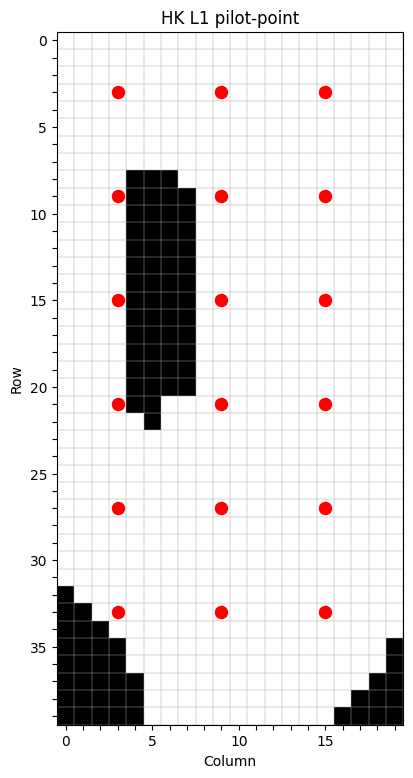

In [37]:
from matplotlib.colors import ListedColormap

pp = df_pp[df_pp.parnme.str.startswith("hk_l1")].copy()

x_edges = np.r_[0.0, np.cumsum(delr)]
y_edges = sr.yul - np.r_[0.0, np.cumsum(delc)]

fig, ax = plt.subplots(figsize=(7, 9))
ax.set_facecolor("white")

inactive = np.ma.masked_where(idomain[0] > 0, idomain[0])
ax.pcolormesh(x_edges, y_edges, inactive, cmap=ListedColormap(["black"]), shading="flat", zorder=1)

for x in x_edges: ax.axvline(x, color="0.65", linewidth=0.35, zorder=2)
for y in y_edges: ax.axhline(y, color="0.65", linewidth=0.35, zorder=2)

ax.scatter(pp["x"], pp["y"], s=65, marker="o", facecolors="red", 
          linewidth=1.6, zorder=3, label="HK Layer 1 pilot points")

x_ticks = x_edges[:-1] + np.diff(x_edges)/2
y_ticks = y_edges[:-1] + np.diff(y_edges)/2

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.set_xticklabels([i if i % 5 == 0 else "" for i in range(len(delr))])
ax.set_yticklabels([i if i % 5 == 0 else "" for i in range(len(delc))])

ax.set(xlim=(x_edges.min(), x_edges.max()), ylim=(y_edges.min(), y_edges.max()),
       aspect="equal", xlabel="Column", ylabel="Row", 
       title="HK L1 pilot-point")

plt.show()

9. Kriging factors (one factor file shared by all property fields)
- K, K33, Ss, Sy가 같은 PP 위치와 같은 spatial range를 쓰므로, interpolation 방식과 weight는 공통으로 써도 됨 (but 각 물성의 PP 값은 서로 별도)

starting interp point loop for 800 points
took 0.538029 seconds


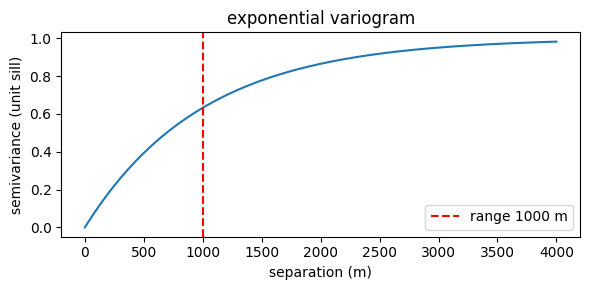

In [38]:
hk1_pp = df_pp[df_pp.parnme.str.startswith("hk_l1")].copy()
gs = pyemu.geostats.GeoStruct(variograms=[pyemu.geostats.ExpVario(contribution=1.0, a=SPATIAL_RANGE_M)],  # 1000m; 4-cell exponential range
                              transform="log") # 통계규칙 정하기
ok = pyemu.geostats.OrdinaryKrige(gs, hk1_pp) # 영향력 계산
ok.calc_factors_grid(sr, var_filename=None, minpts_interp=1, maxpts_interp=20, search_radius=1e10) #설계도 미리 만들기
ok.to_grid_factors_file(str(TEMPLATE / "pp.fac"))
plot_variogram(SPATIAL_RANGE_M); plt.show()

10. Time-multiplier parameter templates (recharge & well, SP2-25)

In [39]:
# Write a PEST template file containing parameter placeholders
def write_mult_tpl(path, names):
    with open(path, "w") as f:
        f.write("ptf ~\n")                 # PEST template-file header
        for n in names:
            f.write(f"~  {n}  ~\n")        # One PEST parameter per line


# Create one recharge multiplier name for each transient stress period
rch_names = [
    f"rchmult_sp{t+2:02d}"
    for t in range(N_TRANS)
]

# Create one shared pumping multiplier name for each transient stress period
wel_names = [
    f"welmult_sp{t+2:02d}"
    for t in range(N_TRANS)
]


# Initial recharge multipliers: all 1.0
np.savetxt(
    TEMPLATE / "rch_mult.dat",
    np.ones(N_TRANS).reshape(-1, 1),
    fmt="%.6e",
)

# Initial pumping multipliers: all 1.0
np.savetxt(
    TEMPLATE / "wel_mult.dat",
    np.ones(N_TRANS).reshape(-1, 1),
    fmt="%.6e",
)


# Create PEST tpl for the two multiplier files
write_mult_tpl(TEMPLATE / "rch_mult.dat.tpl", rch_names)
write_mult_tpl(TEMPLATE / "wel_mult.dat.tpl", wel_names)

# Confirm the number of temporal parameters
print(
    "time multipliers:",
    len(rch_names), "rch +",
    len(wel_names), "wel",
)

time multipliers: 24 rch + 24 wel


11. Info file consumed by forward_run.py

In [40]:
fr_info = {
    "model": MODEL_NAME, "exe": MF6_EXE, "shape": [int(nrow), int(ncol)], "nper": NPER,
    "ntrans": N_TRANS, "nhist": len(HISTORY_SP),
    "wel_cells": [list(c) for c in ref_well_cells],
    "rch_base": ref_rch.tolist(), "wel_base": ref_wel.tolist(),
    "gw": {k: list(v) for k, v in GW.items()},
    "tw_sp": TAILWATER_FORECAST_SP, "hw_sp": HEADWATER_FORECAST_SP, "gw3_sp": GW3_FORECAST_SP,
    "props": PROPS,
}
json.dump(fr_info, open(TEMPLATE / "fr_info.json", "w"), indent=2)
print("wrote fr_info.json")

wrote fr_info.json


12. forward_run.py - apply multipliers, run MF6, extract sim values

- Spatial: property = base x 10**(kriged pilot-point log10-multiplier). 
- Temporal: stress = seasonal base x multiplier. 
- Observations are read from the **01-style** cal_sfr_obs.csv / cal_heads_obs.csv
(sw_1=INFLOW idx39, headwater/tailwater SFR exchange, gw_1/gw_2/gw_3), written to sim_vals.dat in the
fixed obs order.

In [41]:
forward_run = r"""
import json, numpy as np, flopy, pyemu  
info = json.load(open("fr_info.json"))  # load fixed model information
shape = tuple(info["shape"]); nper = info["nper"]; ntrans = info["ntrans"]; nhist = info["nhist"]  # read grid and time settings

def mult_field(prefix):  # make a full-grid multiplier field from pilot points
    a = pyemu.geostats.fac2real(f"{prefix}pp.dat", factors_file="pp.fac", out_file=None)  # interpolate pilot-point values
    return np.asarray(a).reshape(shape)  # reshape to model grid

def prop3(tag):  # build a 3-layer property field
    out = []  # store each layer
    for k in range(3):  # loop through Layers 1–3
        base = np.loadtxt(f"{tag}_base_l{k+1}.dat")  # read homogeneous base field
        out.append(base * mult_field(f"{tag}_l{k+1}"))  # apply pilot-point multiplier
    return np.stack(out)  # combine layers into one array

hk = prop3("hk"); vk = prop3("vk"); ss = prop3("ss")  # create K, K33, and Ss fields
sy1 = np.loadtxt("sy_base_l1.dat") * mult_field("sy_l1")  # create Layer 1 Sy field

sim = flopy.mf6.MFSimulation.load(sim_ws=".", exe_name=info["exe"], verbosity_level=0)  # load local MF6 simulation
gwf = sim.get_model(info["model"])  # get groundwater-flow model
gwf.npf.k.set_data([hk[0], hk[1], hk[2]]); gwf.npf.k33.set_data([vk[0], vk[1], vk[2]])  # update K and K33
gwf.sto.ss.set_data([ss[0], ss[1], ss[2]])  # update specific storage
gwf.sto.sy.set_data([sy1, np.zeros(shape), np.zeros(shape)])  # set Sy only in Layer 1

rm = np.atleast_1d(np.loadtxt("rch_mult.dat")); wm = np.atleast_1d(np.loadtxt("wel_mult.dat"))  # read time multipliers
rb = info["rch_base"]; wb = info["wel_base"]; cells = [tuple(c) for c in info["wel_cells"]]  # read baseline forcing and well cells
idomain0 = gwf.dis.idomain.array[0]  # get Layer 1 active-cell mask
rspd = {0: np.where(idomain0 > 0, rb[0], 0.0)}  # set SP1 baseline recharge
wspd = {0: [[cells[i], -wb[i][0]] for i in range(len(cells))]}  # set SP1 baseline pumping
for t in range(ntrans):  # loop through transient stress periods
    rspd[t+1] = np.where(idomain0 > 0, rb[t+1] * float(rm[t]), 0.0)  # apply recharge multiplier
    wspd[t+1] = [[cells[i], -wb[i][t+1] * float(wm[t])] for i in range(len(cells))]  # apply shared well multiplier
gwf.rcha.recharge.set_data(rspd); gwf.wel.stress_period_data.set_data(wspd)  # update MF6 recharge and wells
sim.write_simulation()  # write updated MF6 input files
pyemu.os_utils.run(info["exe"])  # run MODFLOW 6

import pandas as pd  
sfr = pd.read_csv("cal_sfr_obs.csv"); sfr.columns = [c.strip().lower() for c in sfr.columns]  # read SFR outputs
hds = pd.read_csv("cal_heads_obs.csv"); hds.columns = [c.strip().lower() for c in hds.columns]  # read head outputs
vals = []  # store simulated values in PEST observation order
for sp in range(2, 2 + nhist):                       # SP2..SP13
    vals.append(float(sfr.iloc[sp-1]["sw_1"]))  # terminal-stream flow
    vals.append(float(hds.iloc[sp-1]["gw_1"]))  # groundwater head at GW_1
    vals.append(float(hds.iloc[sp-1]["gw_2"]))  # groundwater head at GW_2
vals.append(float(sfr.iloc[info["tw_sp"]-1]["tailwater_exchange"]))   # forecast tailwater SP13
vals.append(float(sfr.iloc[info["hw_sp"]-1]["headwater_exchange"]))   # forecast headwater SP22
vals.append(float(hds.iloc[info["gw3_sp"]-1]["gw_3"]))                # forecast gw_3 SP22
np.savetxt("sim_vals.dat", np.array(vals).reshape(-1, 1), fmt="%.8e")  # write PEST simulated values
"""
(TEMPLATE / "forward_run.py").write_text(forward_run, encoding="utf-8")  # save external forward-run script
print("wrote forward_run.py")  # confirm file creation

wrote forward_run.py


In [42]:
# forward_run = r"""
# import json, numpy as np, flopy, pyemu
# info = json.load(open("fr_info.json"))
# shape = tuple(info["shape"]); nper = info["nper"]; ntrans = info["ntrans"]; nhist = info["nhist"]

# def mult_field(prefix):
#     a = pyemu.geostats.fac2real(f"{prefix}pp.dat", factors_file="pp.fac", out_file=None)
#     return np.asarray(a).reshape(shape)

# def prop3(tag):
#     out = []
#     for k in range(3):
#         base = np.loadtxt(f"{tag}_base_l{k+1}.dat")
#         out.append(base * mult_field(f"{tag}_l{k+1}"))
#     return np.stack(out)

# hk = prop3("hk"); vk = prop3("vk"); ss = prop3("ss")
# sy1 = np.loadtxt("sy_base_l1.dat") * mult_field("sy_l1")

# sim = flopy.mf6.MFSimulation.load(sim_ws=".", exe_name=info["exe"], verbosity_level=0)
# gwf = sim.get_model(info["model"])
# gwf.npf.k.set_data([hk[0], hk[1], hk[2]]); gwf.npf.k33.set_data([vk[0], vk[1], vk[2]])
# gwf.sto.ss.set_data([ss[0], ss[1], ss[2]])
# gwf.sto.sy.set_data([sy1, np.zeros(shape), np.zeros(shape)])

# rm = np.atleast_1d(np.loadtxt("rch_mult.dat")); wm = np.atleast_1d(np.loadtxt("wel_mult.dat"))
# rb = info["rch_base"]; wb = info["wel_base"]; cells = [tuple(c) for c in info["wel_cells"]]
# idomain0 = gwf.dis.idomain.array[0]
# rspd = {0: np.where(idomain0 > 0, rb[0], 0.0)}
# wspd = {0: [[cells[i], -wb[i][0]] for i in range(len(cells))]}
# for t in range(ntrans):
#     rspd[t+1] = np.where(idomain0 > 0, rb[t+1] * float(rm[t]), 0.0)
#     wspd[t+1] = [[cells[i], -wb[i][t+1] * float(wm[t])] for i in range(len(cells))]
# gwf.rcha.recharge.set_data(rspd); gwf.wel.stress_period_data.set_data(wspd)
# sim.write_simulation()
# pyemu.os_utils.run(info["exe"])

# import pandas as pd
# sfr = pd.read_csv("cal_sfr_obs.csv"); sfr.columns = [c.strip().lower() for c in sfr.columns]
# hds = pd.read_csv("cal_heads_obs.csv"); hds.columns = [c.strip().lower() for c in hds.columns]
# vals = []
# for sp in range(2, 2 + nhist):                       # SP2..SP13
#     vals.append(float(sfr.iloc[sp-1]["sw_1"]))
#     vals.append(float(hds.iloc[sp-1]["gw_1"]))
#     vals.append(float(hds.iloc[sp-1]["gw_2"]))
# vals.append(float(sfr.iloc[info["tw_sp"]-1]["tailwater_exchange"]))   # forecast tailwater SP13
# vals.append(float(sfr.iloc[info["hw_sp"]-1]["headwater_exchange"]))   # forecast headwater SP22
# vals.append(float(hds.iloc[info["gw3_sp"]-1]["gw_3"]))                # forecast gw_3 SP22
# np.savetxt("sim_vals.dat", np.array(vals).reshape(-1, 1), fmt="%.8e")
# """
# (TEMPLATE / "forward_run.py").write_text(forward_run, encoding="utf-8")
# print("wrote forward_run.py")

13. Instruction file (line-based, matches sim_vals.dat order)

In [43]:
hist_names, fore_names = obs_order(HISTORY_SP)
all_names = hist_names + fore_names
np.savetxt(TEMPLATE / "sim_vals.dat", np.zeros(len(all_names)).reshape(-1, 1), fmt="%.8e")
with open(TEMPLATE / "sim_vals.dat.ins", "w") as f:
    f.write("pif ~\n")
    for nm in all_names: f.write(f"l1 !{nm}!\n")
print("obs count:", len(all_names), "=", len(hist_names), "history +", len(fore_names), "forecasts")

obs count: 39 = 36 history + 3 forecasts


14. Build the control file (Pst.from_io_files)

In [44]:
tpls = [str(TEMPLATE / f"{p}pp.dat.tpl") for p in PROPS] + \
       [str(TEMPLATE / "rch_mult.dat.tpl"), str(TEMPLATE / "wel_mult.dat.tpl")]
ins  = [str(TEMPLATE / "sim_vals.dat.ins")]
outs = [str(TEMPLATE / "sim_vals.dat")]
dats = [str(TEMPLATE / f"{p}pp.dat") for p in PROPS] + \
       [str(TEMPLATE / "rch_mult.dat"), str(TEMPLATE / "wel_mult.dat")]
pst = pyemu.Pst.from_io_files(tpls, dats, ins, outs, pst_path=".")
print("npar:", pst.npar, "| nobs:", pst.nobs)

npar: 228 | nobs: 39


15. Parameters - pilot-point multipliers (log) + time multipliers, bounds from Table 1

In [45]:
par = pst.parameter_data
def grp(prefix): return [p for p in par.index if p.lower().startswith(prefix)]
for _, row in pt.iterrows():
    g = grp(row["name"])
    par.loc[g, ["pargp","partrans","parval1","parlbnd","parubnd"]] = \
        [row["name"], "log", 1.0, float(row["mult_lb"]), float(row["mult_ub"])]
tb = time_mult_bounds()
par.loc[grp("rchmult"), ["pargp","partrans","parval1","parlbnd","parubnd"]] = ["rchmult","log",1.0,tb["rch"]["mult_lb"],tb["rch"]["mult_ub"]]
par.loc[grp("welmult"), ["pargp","partrans","parval1","parlbnd","parubnd"]] = ["welmult","log",1.0,tb["wel"]["mult_lb"],tb["wel"]["mult_ub"]]
print("param groups:", sorted(par.pargp.unique()), "| adj par:", pst.npar_adj)

param groups: ['hk_l1', 'hk_l2', 'hk_l3', 'rchmult', 'ss_l1', 'ss_l2', 'ss_l3', 'sy_l1', 'vk_l1', 'vk_l2', 'vk_l3', 'welmult'] | adj par: 228


16. Observations - obsval/weight from synthetic_history_observations.csv; forecasts zero-weight (no truth)

In [46]:
hist_map = read_history_csv(HIST_CSV)         # {obsnme: (observed, weight)} - truth model NOT read
obs = pst.observation_data # get the PEST observation table
for nm in obs.index:
    low = nm.lower()
    if low in fore_names:                                                   # fore_names; forecasts: zero weight, placeholder obsval (no truth)
        obs.loc[nm, ["obsval","weight","obgnme"]] = [0.0, 0.0, "forecast"]
    elif low in hist_map:
        val, wt = hist_map[low]                                             # history observation used in calibration
        grp_name = "sw" if low.startswith("sw_1") else "head"               # assign observation group
        obs.loc[nm, ["obsval","weight","obgnme"]] = [val, wt, grp_name]     # write value, weight, and group into PEST table
    else:
        obs.loc[nm, ["obsval","weight","obgnme"]] = [0.0, 0.0, "unused"]
pst.pestpp_options["forecasts"] = ",".join(fore_names)                      # tell PEST which outputs are forecasts
print("weighted obs:", int((obs.weight > 0).sum()), "| forecasts:", fore_names)



weighted obs: 36 | forecasts: ['tailwater_sp13', 'headwater_sp22', 'gw_3_sp22']


17. Prior covariance - spatial (pilot points) + temporal (time multipliers)

spatial blocks: 10 | temporal: (24, 24) (24, 24)


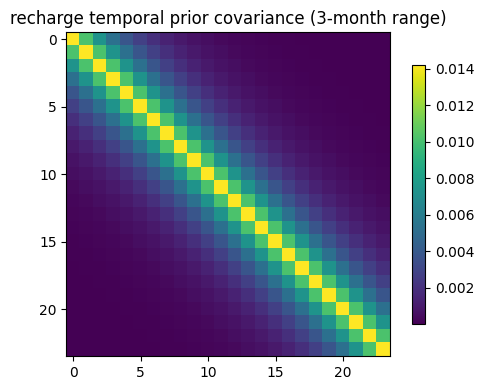

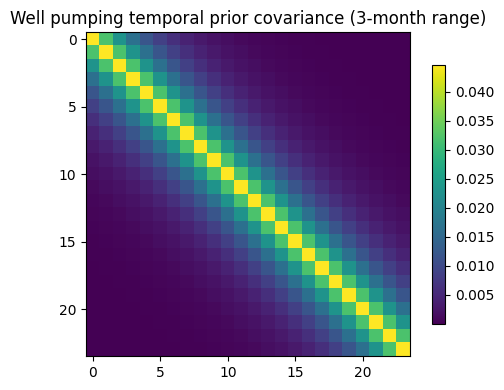

In [47]:
cov_blocks = []
for _, row in pt.iterrows():
    sub = df_pp[df_pp.parnme.str.startswith(row["name"])].copy()
    gs_s = pyemu.geostats.GeoStruct(variograms=[pyemu.geostats.ExpVario(
        contribution=float(row["log10_std"])**2, a=SPATIAL_RANGE_M)], transform="log")
    cov_blocks.append(gs_s.covariance_matrix(sub.x, sub.y, sub.parnme))
tb = time_mult_bounds()
cov_rch = temporal_cov([f"rchmult_sp{t+2:02d}" for t in range(N_TRANS)], N_TRANS, TEMPORAL_RANGE_MONTHS, tb["rch"]["log10_std"])
cov_wel = temporal_cov([f"welmult_sp{t+2:02d}" for t in range(N_TRANS)], N_TRANS, TEMPORAL_RANGE_MONTHS, tb["wel"]["log10_std"])
prior_cov = pyemu.Cov.from_parameter_data(pst)   # diagonal base; fill blocks below
print("spatial blocks:", len(cov_blocks), "| temporal:", cov_rch.shape, cov_wel.shape)

plot_cov(cov_rch, title="recharge temporal prior covariance (3-month range)"); plt.show()

plot_cov(cov_wel, title="Well pumping temporal prior covariance (3-month range)"); plt.show()

Index 0: hk_l1
Index 1: hk_l2
Index 2: hk_l3
Index 3: vk_l1
Index 4: vk_l2
Index 5: vk_l3
Index 6: ss_l1
Index 7: ss_l2
Index 8: ss_l3
Index 9: sy_l1


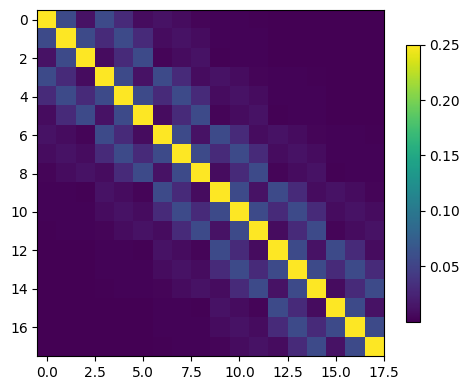

In [48]:
for i, name in enumerate(PROPS):
    print(f"Index {i}: {name}")

plot_cov(cov_blocks[0],); plt.show()

18. Tikhonov (preferred homogeneity from the prior covariance) + SVD

In [49]:
pst.nnz_obs

36

In [50]:
for cb in cov_blocks:  # add spatial-property reg from each covariance block
    pyemu.helpers.first_order_pearson_tikhonov(
        pst, cb, reset=False, abs_drop_tol=0.3
    )  

for cb in (cov_rch, cov_wel):  # add temporal reg for recharge and pumping
    pyemu.helpers.first_order_pearson_tikhonov(
        pst, cb, reset=False, abs_drop_tol=0.3
    )  # create prior-information equations for time multipliers

pst.control_data.pestmode = "regularization"  # use regularized inversion mode

pst.svd_data.maxsing = pst.nnz_obs  # retain at most one singular vector per weighted observation
pst.svd_data.eigthresh = 1.0e-6  # discard numerically weak singular values

pst.model_command = ["python forward_run.py"]  # command PEST runs for each model evaluation

pst.reg_data.phimlim = float(max(pst.nnz_obs, 1))  # target measurement phi: 36
pst.reg_data.phimaccept = pst.reg_data.phimlim * 1.1  # acceptable phi: 10% above target

pst.control_data.noptmax = 0  # run only a pre-calibration check; do not optimise parameters

print(
    "prior information equations:",
    pst.prior_information.shape[0],
    "| PHIMLIM:",
    pst.reg_data.phimlim,
)

getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
getting CC matrix
processing
prior information equations: 132 | PHIMLIM: 36.0


19. Save prior covariance and write the control file (version=1)

In [51]:
# assemble full prior covariance (spatial blocks + temporal blocks) on the diagonal base
full = pyemu.Cov.from_parameter_data(pst)
for cb in cov_blocks + [cov_rch, cov_wel]:
    full.replace(cb)
full.to_binary(str(TEMPLATE / "prior_cov.jcb"))
pst.write(str(TEMPLATE / "freyberg_3l.pst"), version=1)
print("wrote freyberg_3l.pst and prior_cov.jcb")

noptmax:0, npar_adj:228, nnz_obs:36
wrote freyberg_3l.pst and prior_cov.jcb


c:\gwmodel\.venv\Lib\site-packages\pyemu\mat\mat_handler.py:2055: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.records.
c:\gwmodel\.venv\Lib\site-packages\pyemu\mat\mat_handler.py:2074: UserWarning: par name 'hk_l1_i:15_j:15_zone:1' greater than 12 chars
c:\gwmodel\.venv\Lib\site-packages\pyemu\mat\mat_handler.py:2074: UserWarning: par name 'hk_l1_i:15_j:3_zone:1' greater than 12 chars
c:\gwmodel\.venv\Lib\site-packages\pyemu\mat\mat_handler.py:2074: UserWarning: par name 'hk_l1_i:15_j:9_zone:1' greater than 12 chars
c:\gwmodel\.venv\Lib\site-packa

20. Read-check with pestpp-glm (noptmax=0)

In [52]:
r = subprocess.run(["pestpp-glm", "freyberg_3l.pst"], cwd=str(TEMPLATE),
                   capture_output=True, text=True)
print("returncode:", r.returncode)
print("\n".join(r.stdout.splitlines()[-15:]))

returncode: 0
  NPHISTP lowest PHI's:

FINAL OPTIMISATION RESULTS

  Final phi                                           Total : 106.541
  Contribution to phi from observation group         "head" : 74.0204
  Contribution to phi from observation group     "forecast" : 0
  Contribution to phi from observation group           "sw" : 32.5204
  Contribution to phi from observation group     "regul_cc" : 0


pestpp-glm analysis complete...
started at 07/06/26 09:54:27
finished at 07/06/26 09:54:30
took 0.05 minutes


In [53]:
from IPython.display import display, Markdown, Math
import numpy as np

# Active history observations
active_obs = obs.loc[obs.weight > 0].copy()
head_obs = active_obs[active_obs.obgnme == "head"]
sw_obs = active_obs[active_obs.obgnme == "sw"]

# Current uncertainty settings inferred from PEST weights
head_weight = float(head_obs.weight.iloc[0])
head_sigma = 1.0 / head_weight

n_head = len(head_obs)
n_sw = len(sw_obs)
n_total = len(active_obs)

display(Markdown("## Objective functions used in this PESTPP-GLM setup"))

display(Markdown(
    f"**Active history observations:** {n_total} "
    f"({n_head} heads + {n_sw} streamflow observations)"
))

display(Markdown("### 1. Composite measurement objective function"))

display(Math(
    r"\Phi_m = \Phi_{\mathrm{head}} + \Phi_{\mathrm{sw}}"
))

display(Math(
    rf"\Phi_{{\mathrm{{head}}}} = "
    rf"\sum_{{t=\mathrm{{SP2}}}}^{{\mathrm{{SP13}}}} "
    rf"\left[\frac{{h_{{\mathrm{{gw1}},t}}^{{sim}}-h_{{\mathrm{{gw1}},t}}^{{obs}}}}"
    rf"{{{head_sigma:.5f}\ \mathrm{{m}}}}\right]^2 "
    rf"+ "
    rf"\sum_{{t=\mathrm{{SP2}}}}^{{\mathrm{{SP13}}}} "
    rf"\left[\frac{{h_{{\mathrm{{gw2}},t}}^{{sim}}-h_{{\mathrm{{gw2}},t}}^{{obs}}}}"
    rf"{{{head_sigma:.5f}\ \mathrm{{m}}}}\right]^2"
))

display(Math(
    r"\Phi_{\mathrm{sw}} = "
    r"\sum_{t=\mathrm{SP2}}^{\mathrm{SP13}} "
    r"\left["
    r"\frac{q_{\mathrm{sw1},t}^{sim}-q_{\mathrm{sw1},t}^{obs}}"
    r"{0.15\left|q_{\mathrm{sw1},t}^{obs}\right|}"
    r"\right]^2"
))

display(Markdown("### 2. Observation weights"))

display(Math(
    rf"w_h = \frac{{1}}{{\sigma_h}} = "
    rf"\frac{{1}}{{{head_sigma:.5f}\ \mathrm{{m}}}} = "
    rf"{head_weight:.4f}\ \mathrm{{m}}^{{-1}}"
))

display(Math(
    r"w_{q,t} = \frac{1}{0.15\left|q_{\mathrm{sw1},t}^{obs}\right|}"
))

display(Markdown(
    "Forecast observations have zero weight, so they are retained as outputs "
    "but do not contribute to the measurement objective function."
))

display(Math(
    r"\Phi_{\mathrm{forecast}} = 0"
))

display(Markdown("### 3. Regularization objective function"))

display(Math(
    r"\Phi_r = "
    r"\sum_{(i,j)\in E_{\mathrm{spatial}}}"
    r"\left[w_{ij}(z_i-z_j)\right]^2"
    r"+"
    r"\sum_{(i,j)\in E_{\mathrm{temporal}}}"
    r"\left[w_{ij}(z_i-z_j)\right]^2"
))

display(Markdown(
    "Here, the spatial terms constrain related pilot-point parameters, "
    "and the temporal terms constrain related recharge and pumping multipliers."
))

display(Markdown("### 4. Total phi reported by PEST"))

display(Math(
    r"\Phi_{\mathrm{total}} = "
    r"\Phi_{\mathrm{head}} + "
    r"\Phi_{\mathrm{sw}} + "
    r"\Phi_{\mathrm{forecast}} + "
    r"\Phi_r"
))

display(Markdown("### 5. Regularization targets"))

display(Math(
    rf"\Phi_{{m,\mathrm{{target}}}} = "
    rf"\mathrm{{PHIMLIM}} = {pst.reg_data.phimlim:.1f}"
))

display(Math(
    rf"\Phi_{{m,\mathrm{{acceptable}}}} = "
    rf"\mathrm{{PHIMACCEPT}} = {pst.reg_data.phimaccept:.1f}"
))

print(f"Head sigma      : {head_sigma:.5f} m")
print(f"Head weight     : {head_weight:.4f} 1/m")
print(f"History obs     : {n_total} ({n_head} head + {n_sw} streamflow)")
print(f"PHIMLIM         : {pst.reg_data.phimlim:.1f}")
print(f"PHIMACCEPT      : {pst.reg_data.phimaccept:.1f}")
print(f"Prior equations : {pst.prior_information.shape[0]}")

## Objective functions used in this PESTPP-GLM setup

**Active history observations:** 36 (24 heads + 12 streamflow observations)

### 1. Composite measurement objective function

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

### 5. Regularization targets

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Head sigma      : 0.15000 m
Head weight     : 6.6667 1/m
History obs     : 36 (24 head + 12 streamflow)
PHIMLIM         : 36.0
PHIMACCEPT      : 39.6
Prior equations : 132


In [54]:
# Keep only history observations used in the objective function
diag = obs.loc[obs.weight > 0].copy()

# Assign physical units by observation type
diag["unit"] = np.where(
    diag.index.str.lower().str.startswith("sw_1"),
    "m$^3$/d",   # SFR flow
    "m",         # groundwater head
)

# Weight is interpreted as 1 / standard deviation
diag["implied_sigma"] = 1.0 / diag["weight"]

# Useful for checking the flow-observation relative uncertainty
diag["implied_relative_sigma"] = (
    diag["implied_sigma"] / diag["obsval"].abs()
)

summary = (
    diag.groupby(["obgnme", "unit"])
    .agg(
        n_obs=("obsval", "size"),
        weight_min=("weight", "min"),
        weight_max=("weight", "max"),
        sigma_min=("implied_sigma", "min"),
        sigma_max=("implied_sigma", "max"),
        rel_sigma_min=("implied_relative_sigma", "min"),
        rel_sigma_max=("implied_relative_sigma", "max"),
    )
)

display(summary)
display(diag[["obsval", "weight", "unit", "implied_sigma",
              "implied_relative_sigma"]])

,,n_obs,weight_min,weight_max,sigma_min,sigma_max,rel_sigma_min,rel_sigma_max
obgnme,unit,,,,,,,
head,m,24,6.666667,6.666667,0.150000,0.150000,0.004258,0.004407
sw,m$^3$/d,12,0.003529,0.006776,147.586307,283.402166,0.150000,0.150000


,obsval,weight,unit,implied_sigma,implied_relative_sigma
gw_1_sp02,35.087114,6.666667,m,0.150000,0.004275
gw_1_sp03,35.152606,6.666667,m,0.150000,0.004267
gw_1_sp04,35.229535,6.666667,m,0.150000,0.004258
gw_1_sp05,35.218376,6.666667,m,0.150000,0.004259
gw_1_sp06,35.126835,6.666667,m,0.150000,0.004270
gw_1_sp07,35.001005,6.666667,m,0.150000,0.004286
gw_1_sp08,34.841990,6.666667,m,0.150000,0.004305
gw_1_sp09,34.743723,6.666667,m,0.150000,0.004317
gw_1_sp10,34.716441,6.666667,m,0.150000,0.004321
gw_1_sp11,34.784967,6.666667,m,0.150000,0.004312
